# Day 5 — End-to-End Leak-Free Machine Learning Pipeline

The goal of this mini-project is to build a complete classification workflow for predicting diabetes while keeping preprocessing, model training, hyperparameter tuning, and evaluation organized and free from data leakage.

Unlike the previous workflow, where preprocessing steps such as encoding were performed manually before model training, this notebook combines preprocessing and modeling into a single `Pipeline`.

The workflow will include:

- Data cleaning and exploratory data analysis (EDA)
- Feature engineering based on the findings from Day 4
- Separate preprocessing for numeric and categorical features using `ColumnTransformer`
- A baseline Random Forest pipeline
- Hyperparameter tuning with `GridSearchCV`
- 5-fold cross-validation using F1 score
- A single final evaluation on the held-out test set

This structure makes the workflow easier to reproduce and ensures that preprocessing is learned only from the appropriate training data.

## Dataset Overview

The dataset contains demographic and medical information that may be useful for predicting whether a patient has diabetes.

The target variable is:

- `diabetes = 0`: patient is not classified as diabetic
- `diabetes = 1`: patient is classified as diabetic

Before building the model, the dataset will first be checked for missing values, duplicate observations, class imbalance, and relationships between important predictors and the target.

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, classification_report, confusion_matrix

Load & clean the dataset:

In [2]:
df = pd.read_csv("diabetes_prediction_dataset.csv") # same dataset as day 4

print(df.shape)
print(df.isna().sum())
print("Duplicates:", df.duplicated().sum())

(100000, 9)
gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64
Duplicates: 3854


In [3]:
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)

print(df.shape)

(96146, 9)


### Cleaning Result

The original dataset contained **100,000 observations**.

A total of **3,854 duplicate rows** were identified and removed, leaving **96,146 unique observations** for analysis.

Removing duplicates ensures that repeated records do not receive unnecessary extra weight during model training.

# Exploratory Data Analysis

Before constructing the machine learning pipeline, a short exploratory analysis is performed to understand the structure of the prediction problem.

The purpose of this EDA is not to select a model based on the test set. Instead, it helps answer several useful questions:

- Is the target variable balanced?
- Are diabetic and non-diabetic patients distributed differently by age?
- Does BMI appear related to diabetes?
- How do HbA1c and blood glucose differ between the two classes?
- Do hypertension and heart disease appear associated with diabetes?

These observations can also provide context for the engineered features used later in the pipeline.

In [14]:
print(df["diabetes"].value_counts())
print("\nClass proportions:")
print(df["diabetes"].value_counts(normalize=True))

diabetes
0    87664
1     8482
Name: count, dtype: int64

Class proportions:
diabetes
0    0.91178
1    0.08822
Name: proportion, dtype: float64


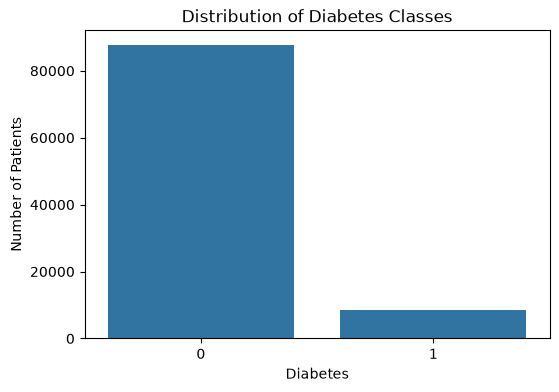

In [16]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="diabetes")

plt.title("Distribution of Diabetes Classes")
plt.xlabel("Diabetes")
plt.ylabel("Number of Patients")

plt.show()

### Target Class Distribution

The target variable is noticeably imbalanced.

Approximately **8.8% of the observations belong to the diabetic class**, while about **91.2% belong to the non-diabetic class**.

This imbalance is important because accuracy alone could be misleading. A model predicting the majority class most of the time could achieve high accuracy while performing poorly at identifying diabetic patients.

For this reason, **F1 score** will be used as the main model evaluation metric. F1 balances precision and recall and is more informative for this classification problem than accuracy alone.

The class imbalance also motivates using a **stratified train/test split**, which preserves approximately the same class proportions in both datasets.

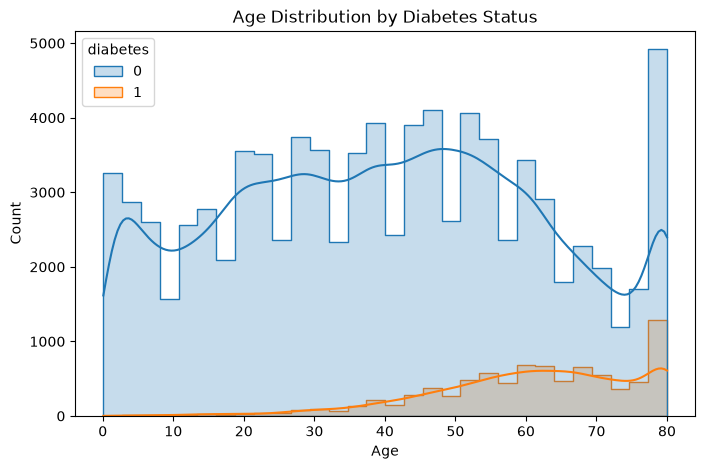

,mean,median
diabetes,,
0,39.943229,40.0
1,60.925961,62.0


In [20]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="age",
    hue="diabetes",
    bins=30,
    kde=True,
    element="step"
)

plt.title("Age Distribution by Diabetes Status")
plt.xlabel("Age")
plt.ylabel("Count")

plt.show()

df.groupby("diabetes")["age"].agg(["mean", "median"])

### Age and Diabetes

Age shows a noticeable relationship with diabetes status.

In this dataset:

- Non-diabetic patients have an average age of approximately **39.9 years**
- Diabetic patients have an average age of approximately **60.9 years**

The age distribution of diabetic patients is therefore shifted toward older individuals.

This suggests that age contains meaningful predictive information and should remain an important numeric feature in the model.

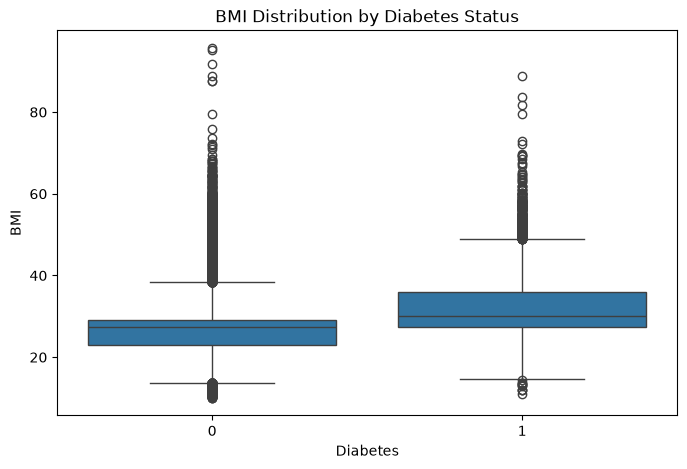

,mean,median
diabetes,,
0,26.869003,27.320
1,31.997755,29.985


In [22]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="diabetes",
    y="bmi"
)

plt.title("BMI Distribution by Diabetes Status")
plt.xlabel("Diabetes")
plt.ylabel("BMI")

plt.show()

df.groupby("diabetes")["bmi"].agg(["mean", "median"])

### BMI and Diabetes

BMI also appears to differ between the two target classes.

The mean BMI is approximately:

- **26.9** for non-diabetic patients
- **32.0** for diabetic patients

Diabetic observations therefore tend to have higher BMI values.

This supports the feature-engineering decision from Day 4 to create a categorical BMI feature. While the original continuous `bmi` measurement is retained, `BMI_category` provides an additional representation that groups patients into clinically interpretable ranges such as normal, overweight, and obese.

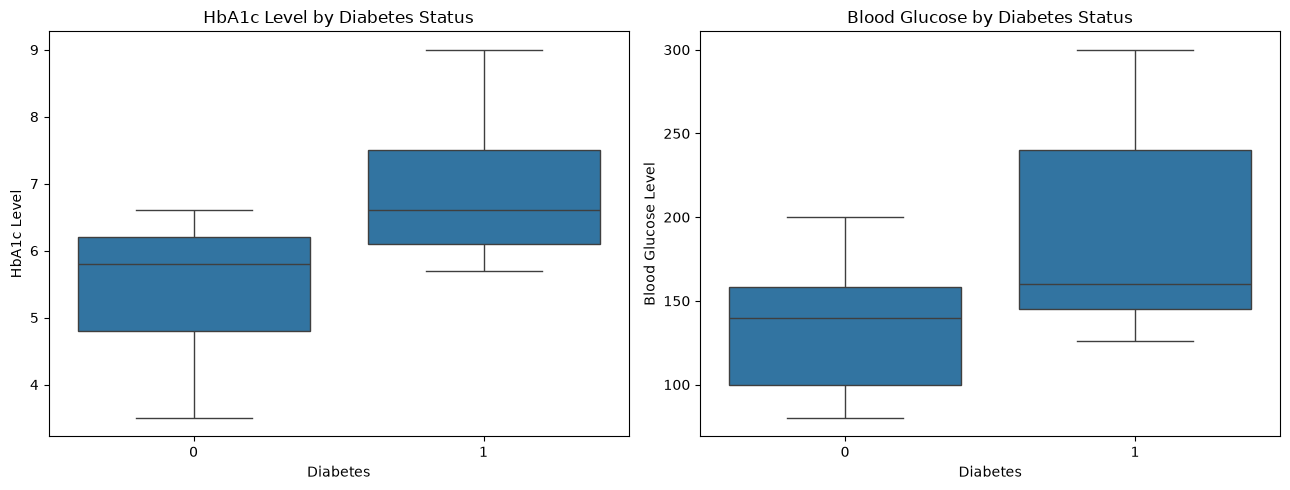

,HbA1c_level,blood_glucose_level
diabetes,,
0,5.396936,132.818489
1,6.934827,194.026173


In [26]:
fig, axes = plt.subplots(1, 2, figsize=(13,5))

sns.boxplot(
    data=df,
    x="diabetes",
    y="HbA1c_level",
    ax=axes[0]
)

axes[0].set_title("HbA1c Level by Diabetes Status")
axes[0].set_xlabel("Diabetes")
axes[0].set_ylabel("HbA1c Level")


sns.boxplot(
    data=df,
    x="diabetes",
    y="blood_glucose_level",
    ax=axes[1]
)

axes[1].set_title("Blood Glucose by Diabetes Status")
axes[1].set_xlabel("Diabetes")
axes[1].set_ylabel("Blood Glucose Level")

plt.tight_layout()
plt.show()

df.groupby("diabetes") [["HbA1c_level", "blood_glucose_level"]].mean()

### Glycemic Measurements and Diabetes

The two direct blood-sugar-related measurements show some of the clearest differences between the classes.

On average:

| Group | HbA1c | Blood Glucose |
|---|---:|---:|
| Non-diabetic | ~5.40 | ~132.82 |
| Diabetic | ~6.93 | ~194.03 |

Both HbA1c and blood glucose are substantially higher among diabetic observations.

This provides the motivation for the engineered feature, `critical_blood_sugar`, which combines clinically significant thresholds from these two variables into a single binary indicator.

The original measurements are still retained because they contain more detailed information, while the engineered flag provides the model with an additional threshold-based representation.

### Engineered Features :

In [ ]:
bmi_labels = ["underweight", "normal", "overweight", "obese"]
bins = [0, 18.5, 25, 30, 100]

df["BMI_category"] = pd.cut( df["bmi"] , bins=bins , labels=bmi_labels , include_lowest=True)


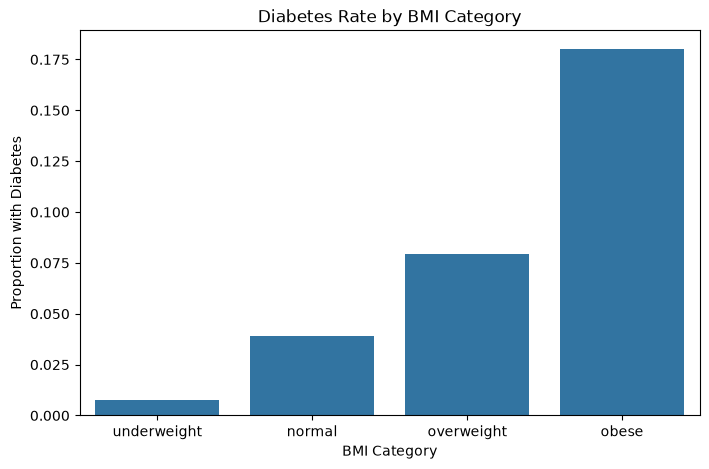

In [ ]:
bmi_diabetes_rate = (df.groupby("BMI_category", observed=False) ["diabetes"].mean().reset_index() )

plt.figure(figsize=(8,5))

sns.barplot(data=bmi_diabetes_rate,x="BMI_category", y="diabetes")

plt.title("Diabetes Rate by BMI Category")
plt.xlabel("BMI Category")
plt.ylabel("Proportion with Diabetes")

plt.show()

### Engineered Feature: Diabetes Rate Across BMI Categories

Grouping BMI into categories makes the relationship with diabetes easier to interpret.

The diabetes rate increases substantially across the BMI groups:

- Underweight patients have the lowest diabetes rate
- Normal-weight patients remain relatively low
- Overweight patients show a higher rate
- Obese patients have the highest diabetes rate

In this dataset, approximately **18% of patients in the obese category have diabetes**, compared with less than **1% of the underweight group**.

This trend supports keeping both representations:

- `bmi` preserves the detailed continuous measurement
- `BMI_category` provides a higher-level categorical representation of BMI ranges

The model can determine whether either representation contributes useful predictive information.

In [ ]:
df["critical_blood_sugar"] = ((df["HbA1c_level"] >= 6.5) | (df["blood_glucose_level"] >= 126) ).astype(int)

print(df["critical_blood_sugar"].value_counts())

critical_blood_sugar
1    73782
0    22364
Name: count, dtype: int64


### Engineered Feature: Critical Blood Sugar

`critical_blood_sugar` is a binary feature derived from HbA1c and blood glucose measurements.

It becomes `1` when either:

- HbA1c is at least 6.5, or
- blood glucose is at least 126

Otherwise, it is assigned `0`.

## EDA Summary

The exploratory analysis revealed several useful characteristics of the dataset:

1. **The target is imbalanced.**  
   Only about 8.8% of observations belong to the diabetic class. Therefore, F1 score is more appropriate than relying only on accuracy, and the train/test split should preserve class proportions using stratification.

2. **Age differs strongly between the classes.**  
   Diabetic patients are substantially older on average.

3. **BMI is associated with diabetes.**  
   Diabetes becomes increasingly common across higher BMI categories, supporting the engineered `BMI_category` feature.

4. **HbA1c and blood glucose contain strong class separation.**  
   Both measurements are considerably higher among diabetic observations, motivating the engineered `critical_blood_sugar` indicator.

The EDA therefore supports keeping a combination of numeric, binary, and categorical variables.

The next step is to construct a preprocessing workflow capable of handling these different feature types without manually transforming the complete dataset.

### Preparing the Modeling Data

The target variable is separated from the predictors before training.

Categorical features are kept in their original form because encoding will be handled later inside the `ColumnTransformer`, helping keep preprocessing inside the pipeline.

The data is split into 80% training and 20% testing.

Because the target is imbalanced, `stratify=y` is used to preserve similar diabetes class proportions in both sets.

**Why use stratify?**  

- diabetes classes are imbalanced.    
- Without stratification, the train and test sets aren't explicitly guaranteed to preserve the same diabetes/non-diabetes proportions.

In [28]:
X = df.drop(columns=["diabetes"])

y = df["diabetes"]

X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42, stratify=y)

To verify Stratify:

In [7]:
print("Full dataset:")
print(y.value_counts(normalize=True))

print("\nTraining set:")
print(y_train.value_counts(normalize=True))

print("\nTest set:")
print(y_test.value_counts(normalize=True))

Full dataset:
diabetes
0    0.91178
1    0.08822
Name: proportion, dtype: float64

Training set:
diabetes
0    0.911774
1    0.088226
Name: proportion, dtype: float64

Test set:
diabetes
0    0.911804
1    0.088196
Name: proportion, dtype: float64


The class proportions remain almost identical across the complete dataset, training set, and test set, confirming that the stratified split worked correctly.

Identify numeric and categorical columns:

In [8]:
numeric_cols = [
    "age",
    "hypertension",
    "heart_disease",
    "bmi",
    "HbA1c_level",
    "blood_glucose_level",
    "critical_blood_sugar"
]

categorical_cols = [
    "gender",
    "smoking_history",
    "BMI_category"
]

print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)

Numeric columns: ['age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level', 'blood_glucose_level', 'critical_blood_sugar']
Categorical columns: ['gender', 'smoking_history', 'BMI_category']


### Preprocessing with `ColumnTransformer`


Numeric variables can be standardized using `StandardScaler`.

Categorical variables must first be converted into a numerical representation using `OneHotEncoder`.

 `ColumnTransformer` allows both transformations to exist inside one preprocessing object.

This provides two advantages:

1. Different column groups receive the correct transformation.
2. The preprocessing can be placed inside the pipeline, preventing preprocessing from being fitted on validation or test observations.

In [ ]:
preprocessor = ColumnTransformer([("num", StandardScaler(), numeric_cols) ,
                                 ( "cat",  OneHotEncoder(handle_unknown="ignore"),  categorical_cols)  ])

   # handle_unknown="ignore" : Suppose the training data contains : --never--former--current--
    #    so if later some new dataset contains another category. OneHotEncoder can throw an error.

pipe = Pipeline([ ("preprocessor", preprocessor) , ("model", RandomForestClassifier(random_state=42)) ]) 

pipe_baseline = Pipeline([ ("preprocessor", preprocessor) , ("model", RandomForestClassifier(random_state=42)) ]) # to use for baseline prediction

Fitting & predicting using the Baseline-pipeline:

In [ ]:
baseline_scores = cross_val_score(
    pipe_baseline,
    X_train,
    y_train,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

print("Baseline fold scores:", baseline_scores)
print(f"Baseline mean CV F1: {baseline_scores.mean():.4f}")
print(f"Baseline CV standard deviation: {baseline_scores.std():.4f}")

Baseline fold scores: [0.79592703 0.78767123 0.789586   0.80100756 0.77508651]
Baseline mean CV F1: 0.7899
Baseline CV standard deviation: 0.0088


#### Hyperparameter Tuning with GridSearchCV

The next step is to test multiple Random Forest configurations.

Because the classifier is now located inside the pipeline under the step name `model`, its hyperparameters are referenced using the syntax:

`model__parameter_name`

For example:

- `model__n_estimators`
- `model__max_depth`
- `model__min_samples_split`

The double underscore tells Scikit-learn to access a parameter belonging to a specific pipeline step.


In [ ]:
param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [5, 10, None],
    "model__min_samples_split": [2, 5]
}

grid = GridSearchCV( estimator=pipe, param_grid=param_grid, cv=5, scoring="f1", n_jobs=-1)

grid.fit(X_train, y_train)

print("Best parameters:")
print(grid.best_params_)

print("\nBest CV F1:")
print(grid.best_score_)

Best parameters:
{'model__max_depth': None, 'model__min_samples_split': 5, 'model__n_estimators': 100}

Best CV F1:
0.8005789145736477


#### What Happens During Each Grid Search Fold?

For each hyperparameter combination, training data is divided into five folds.

**For each iteration:**

1. Four folds become the temporary training portion.
2. The `StandardScaler`& `OneHotEncoder` is fitted only on those four folds.
3. The transformed data is used to train the Random Forest.
4. The remaining fold is transformed using the already-fitted preprocessing steps.
5. F1 score is calculated on that validation fold.

#### Tuned VS Untuned F1:

In [ ]:

print(f"Baseline mean CV F1: {baseline_scores.mean():.4f}")

print(f"Tuned best CV F1:    {grid.best_score_:.4f}")

cv_improvement = grid.best_score_ - baseline_scores.mean()

print(f"CV F1 improvement:   {cv_improvement:.4f}")



Baseline mean CV F1: 0.7899
Tuned best CV F1:    0.8006
CV F1 improvement:   0.0107


#### Baseline vs Tuned Model

**comparison between:**
- the baseline model's cross-validated F1 score, and
- the tuned model's best cross-validated F1 score.

Both values are calculated from the training data.

**A small difference is not necessarily a failure.**    
- It may indicate that the Random Forest's default settings were already well suited to this dataset.    
  OR    
- That the tested hyperparameter range does not strongly affect performance. 